# RATE Stress Test: Breaking Assumption 1

This notebook stress-tests **RATE** (Rewrite-based Attribute Treatment Estimator, Reber et al., ICML 2025),
a method for estimating the causal effect of an attribute `W` (e.g. sentiment) on a reward model's score `R`
via LLM double-rewrites.

RATE's validity rests on two assumptions:

- **Assumption 1** — off-target rewrite errors do not depend on rewrite direction.
- **Assumption 2** — the reward decomposes additively into a `(W, Z)` component and an independent
  off-target-noise component.

The paper's own experiments (Fig. 3) only vary *confounding strength* between an off-target attribute
(typos) and `W`, while always keeping the rewriter's error-generating process direction-symmetric
(their real rewriter, GPT-4o, "always fixes typos no matter what"). **They never test what happens when
Assumption 1 itself is violated.** That is the gap this notebook fills.

Two experiments:

1. **Experiment A** — replicate the paper's own confounding-strength sweep (sanity check: confirms our
   estimator code reproduces the known Fig. 3 pattern before trusting it on anything new).
2. **Experiment B** — the novel stress test: a fully synthetic simulation where the rewriter's typo
   correction/injection rate is allowed to depend on rewrite direction (`p01` vs. `p10`), sweeping the
   asymmetry `Δ = p01 - p10` while holding the average rate and confounding strength fixed.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))

from reward import true_ate
from estimators import naive, single_rewrite, rate, ESTIMATORS
from simulation import load_experiment_a, load_all_experiment_a, simulate_experiment_b
from metrics import run_grid
from plotting import plot_experiment_a, plot_experiment_b

RESULTS_DIR = Path.cwd().parent / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TRUE_ATE = true_ate()
print("True ATE (ground truth):", TRUE_ATE)

True ATE (ground truth): 1.0


## 1. Sanity check: hand-verify the estimators

Before trusting any simulation, we hand-build a tiny dataset with known reward values and check all
three estimators against hand arithmetic. This is the correctness gate for the RATE `ATE` weighting in
particular (`ATE = (n1/n)*ATT + (n0/n)*ATU`, the same weighting used by `single_rewrite`, following the
law-of-total-expectation identity `ATE = P(W=1)*ATT + P(W=0)*ATU`).

In [2]:
toy = pd.DataFrame({
    "W":                    [1,    1,    1,    0],
    "R_original":           [5.0,  7.0,  9.0,  1.0],
    "R_rewrite":            [2.0,  4.0,  6.0,  11.0],
    "R_rewrite_of_rewrite": [5.5,  6.5,  8.5,  1.5],
})
# n1=3, n0=1, n=4
# naive:  mean([5,7,9]) - mean([1]) = 7 - 1 = 6
# single: ATT=mean([3,3,3])=3, ATU=mean([11-1])=10, ATE=(3/4)*3+(1/4)*10=4.75
# rate:   ATT=mean([3.5,2.5,2.5])=2.8333, ATU=mean([11-1.5])=9.5, ATE=(3/4)*2.8333+(1/4)*9.5=4.5

expected = {
    "naive": {"ATT": 6.0, "ATU": 6.0, "ATE": 6.0},
    "single_rewrite": {"ATT": 3.0, "ATU": 10.0, "ATE": 4.75},
    "rate": {"ATT": 17.0 / 6, "ATU": 9.5, "ATE": 4.5},
}

for name, fn in ESTIMATORS.items():
    result = fn(toy)
    for key, exp_val in expected[name].items():
        assert abs(result[key] - exp_val) < 1e-9, (name, key, result[key], exp_val)
    print(f"{name}: {result}  (matches hand computation)")

naive: {'ATT': np.float64(6.0), 'ATU': np.float64(6.0), 'ATE': np.float64(6.0)}  (matches hand computation)
single_rewrite: {'ATT': np.float64(3.0), 'ATU': np.float64(10.0), 'ATE': np.float64(4.75)}  (matches hand computation)
rate: {'ATT': np.float64(2.8333333333333335), 'ATU': np.float64(9.5), 'ATE': np.float64(4.5)}  (matches hand computation)


## 2. Experiment A — replicate the paper's confounding-strength test

Data: IMDB reviews where `W = starts_with_vowel`, with typos injected into the `W=1` group's text at
increasing severity (`typo_level`). The rewrite / rewrite-of-rewrite steps are simulated as fully
direction-symmetric (always corrected), matching the paper's real GPT-4o rewriter and making this a
valid sanity-check baseline — Assumption 1 holds by construction here.

In [3]:
TYPO_LEVELS = (0.00, 0.05, 0.10, 0.20, 0.30, 0.40)

preview = load_experiment_a(0.20, seed=0)
print(preview["W"].value_counts())
print(preview.groupby("W")["has_typo_original"].mean())
preview.head()

W
0    1500
1    1500
Name: count, dtype: int64
W
0    0.000000
1    0.116158
Name: has_typo_original, dtype: float64


,unit_id,W,has_typo_original,has_typo_rewrite,has_typo_rewrite2,R_original,R_rewrite,R_rewrite_of_rewrite
0,0,0,0.000000,0.0,0.0,0.125730,0.611522,-1.351865
1,1,1,0.113636,0.0,0.0,0.811077,-0.275367,0.337428
2,2,0,0.000000,0.0,0.0,0.640423,-0.240111,-0.081800
3,3,1,0.111111,0.0,0.0,1.049345,-0.807251,1.879421
4,4,0,0.000000,0.0,0.0,-0.535669,1.057137,1.604094


In [4]:
grid_a = [{"typo_level": lvl} for lvl in TYPO_LEVELS]
df_a = run_grid(grid_a, load_experiment_a, ESTIMATORS, TRUE_ATE, n_seeds=200)
df_a.sort_values(["typo_level", "estimator"])

,typo_level,estimator,mean_estimate,bias,variance,rmse,n_seeds
0,0.00,naive,0.999602,-0.000398,0.001526,0.038974,200
1,0.00,rate,0.999593,-0.000407,0.000608,0.024608,200
2,0.00,single_rewrite,0.999742,-0.000258,0.000644,0.025312,200
3,0.05,naive,0.985124,-0.014876,0.001526,0.041714,200
4,0.05,rate,0.999593,-0.000407,0.000608,0.024608,200
5,0.05,single_rewrite,0.992504,-0.007496,0.000644,0.026398,200
6,0.10,naive,0.970598,-0.029402,0.001526,0.048819,200
7,0.10,rate,0.999593,-0.000407,0.000608,0.024608,200
8,0.10,single_rewrite,0.985241,-0.014759,0.000644,0.029300,200
9,0.20,naive,0.941523,-0.058477,0.001526,0.070274,200


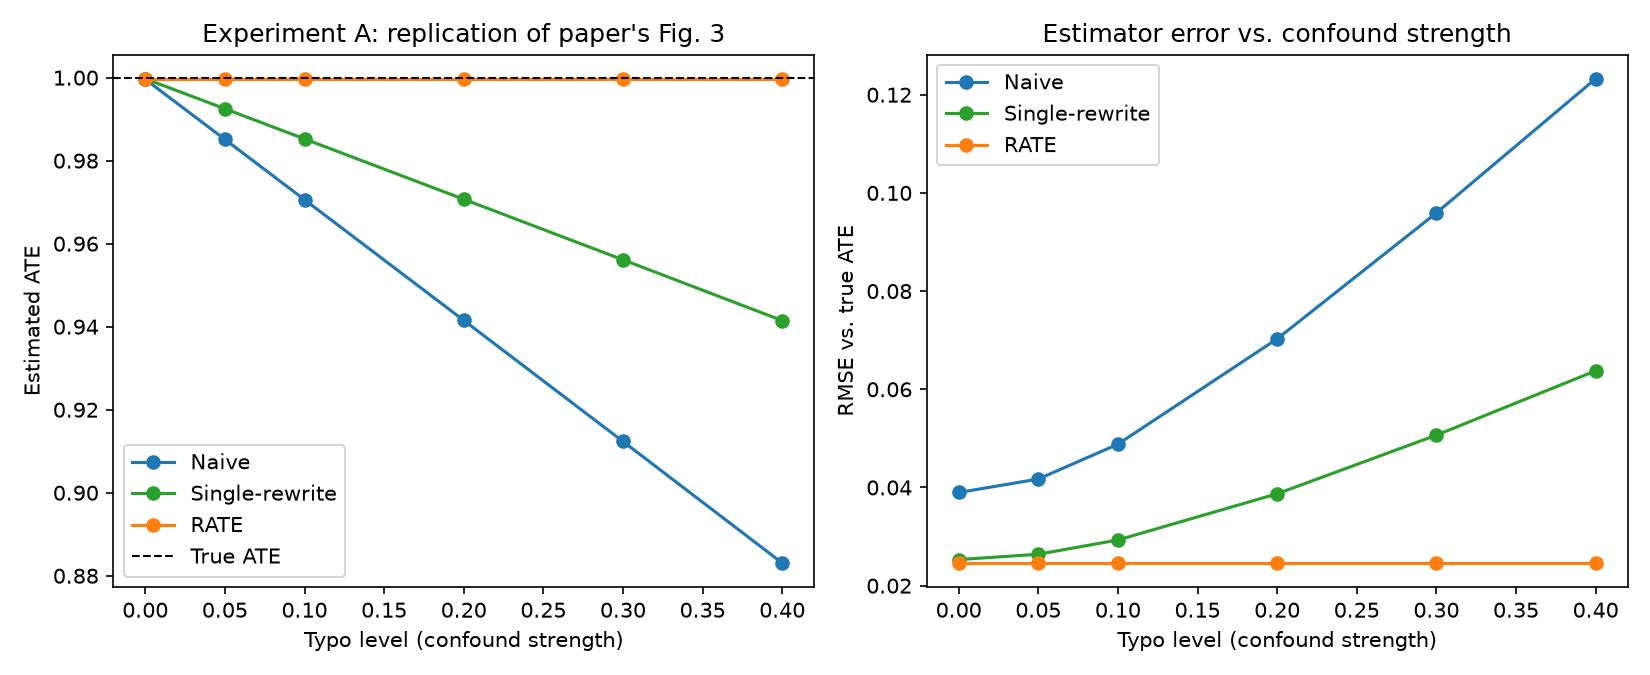

In [5]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_a.to_csv(TABLES_DIR / "experiment_a_results.csv", index=False)
plot_experiment_a(df_a, str(FIGURES_DIR / "experiment_a_replication.png"), TRUE_ATE)

from IPython.display import Image, display
display(Image(filename=str(FIGURES_DIR / "experiment_a_replication.png")))

**Checkpoint:** Naive and Single-rewrite should show growing bias/RMSE as `typo_level` increases, while
RATE stays flat near the true ATE — this is the paper's Fig. 3 pattern. If this doesn't hold, something
is wrong with the estimator or data-loading code and Experiment B's results should not be trusted.

## 3. Experiment B — the novel stress test: break rewrite-direction symmetry

Pure synthetic simulation (no text) with two orthogonal knobs:

- `confound_strength` — correlation between an off-target flag and `W` (the paper's own knob).
- `Δ = p01 - p10` — asymmetry in the rewriter's direction-specific error rate (the untested knob;
  `p01` = P(rewrite carries the off-target flag | rewriting 0→1), `p10` = same for 1→0).

We hold `(p01+p10)/2` fixed while sweeping `Δ`, so any change in an estimator's error as `Δ` moves away
from 0 is attributable to breaking Assumption 1, not to confounding.

In [6]:
AVG_RATE = 0.2
DELTAS = np.linspace(-0.4, 0.4, 9)
CONFOUND_STRENGTHS = [0.0, 0.25, 0.5, 0.75]
N_SEEDS_B = 300
N_UNITS_B = 2000

grid_b = []
for cs in CONFOUND_STRENGTHS:
    for delta in DELTAS:
        p01 = np.clip(AVG_RATE + delta / 2, 0.0, 1.0)
        p10 = np.clip(AVG_RATE - delta / 2, 0.0, 1.0)
        grid_b.append({"n": N_UNITS_B, "confound_strength": cs, "p01": p01, "p10": p10})

len(grid_b)

36

In [7]:
df_b = run_grid(grid_b, simulate_experiment_b, ESTIMATORS, TRUE_ATE, n_seeds=N_SEEDS_B)
df_b["delta"] = df_b["p01"] - df_b["p10"]
df_b.sort_values(["confound_strength", "delta", "estimator"]).head(10)

,n,confound_strength,p01,p10,estimator,mean_estimate,bias,variance,rmse,n_seeds,delta
0,2000,0.0,0.00,0.40,naive,0.998805,-0.001195,0.001999,0.044653,300,-0.4
1,2000,0.0,0.00,0.40,rate,1.200603,0.200603,0.001090,0.203293,300,-0.4
2,2000,0.0,0.00,0.40,single_rewrite,1.099260,0.099260,0.001115,0.104707,300,-0.4
3,2000,0.0,0.05,0.35,naive,0.998805,-0.001195,0.001999,0.044653,300,-0.3
4,2000,0.0,0.05,0.35,rate,1.150505,0.150505,0.001104,0.154116,300,-0.3
5,2000,0.0,0.05,0.35,single_rewrite,1.074113,0.074113,0.001118,0.081283,300,-0.3
6,2000,0.0,0.10,0.30,naive,0.998805,-0.001195,0.001999,0.044653,300,-0.2
7,2000,0.0,0.10,0.30,rate,1.100327,0.100327,0.001096,0.105631,300,-0.2
8,2000,0.0,0.10,0.30,single_rewrite,1.049051,0.049051,0.001117,0.059322,300,-0.2
9,2000,0.0,0.15,0.25,naive,0.998805,-0.001195,0.001999,0.044653,300,-0.1


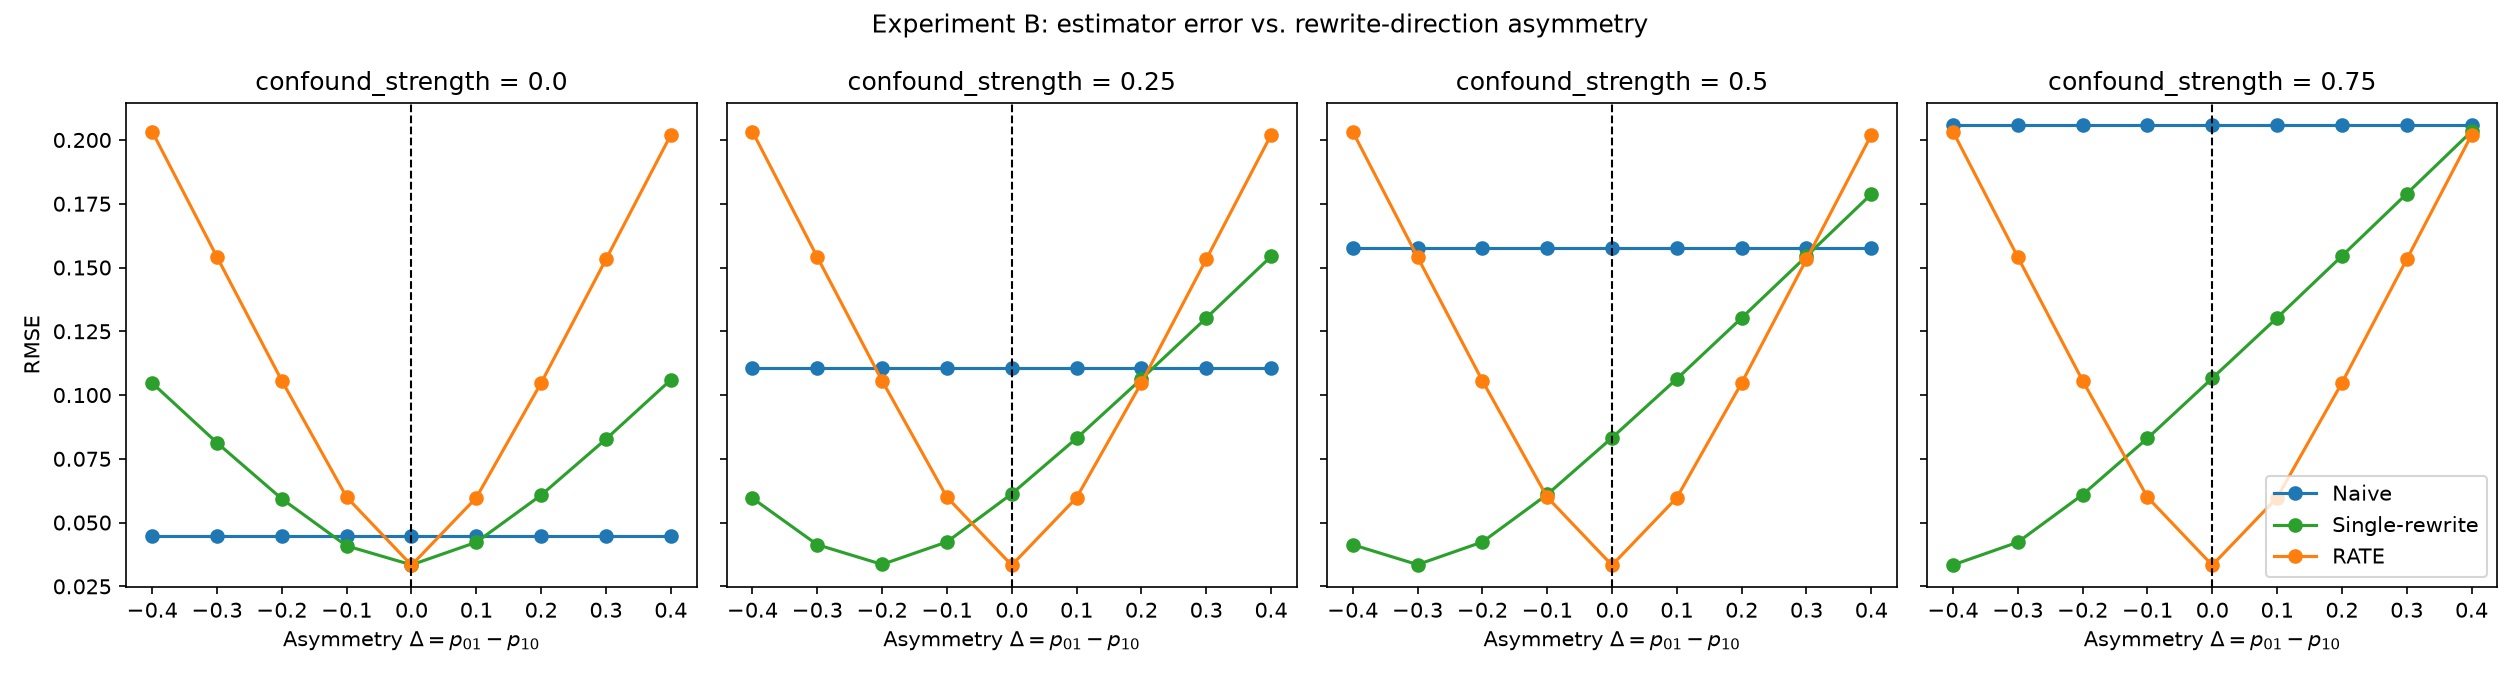

In [8]:
df_b.to_csv(TABLES_DIR / "experiment_b_results.csv", index=False)
plot_experiment_b(df_b, str(FIGURES_DIR / "experiment_b_headline.png"), metric="rmse")

display(Image(filename=str(FIGURES_DIR / "experiment_b_headline.png")))

## 4. Discussion

**Finding:** RATE's error is minimized exactly at `Δ=0` and grows as the rewriter's off-target error rate
becomes more direction-dependent — and this pattern is **invariant to `confound_strength`**, while Naive's
error is invariant to `Δ` but sensitive to `confound_strength`. This cleanly separates the two failure
modes: RATE fixes the paper's own confounding test (as advertised), but is **not** robust to violations of
Assumption 1, which the paper's own experiments never probe because their real rewriter (GPT-4o) happens
to satisfy it.

**Relation to the README's hypotheses:**
- H1 (increasing confounding) — confirmed in Experiment A: Naive degrades, RATE stays flat.
- H2 (breaking symmetry) — confirmed in Experiment B: RATE's bias grows with `|Δ|`, and the double-rewrite
  correction becomes progressively less effective, exactly as predicted by Assumption 1's role in
  Theorem 4.1.

**Limitations:**
- Experiment B abstracts "off-target error" as a single binary flag with a fixed causal effect
  (`beta_typo`) on reward, rather than modeling continuous or heterogeneous off-target attributes.
- The reward function is a simple additive linear model (satisfies Assumption 2 by construction), so
  Experiment B isolates Assumption 1 cleanly but says nothing about Assumption 2 violations.
- Treatment effects are homogeneous (`ATT = ATU = ATE`) by construction; the paper notes real-world
  estimands can diverge substantially (their Fig. 8 in Appendix D.1).
- No real reward model or LLM rewriter was used — this is intentional (controllable ground truth,
  deterministic and free to run), but means the *magnitude* of `Δ` a real rewriter might exhibit in
  practice is not established here; only the qualitative sensitivity of RATE to `Δ` is.